In [2]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import os
import sys
import re

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities

# Load Simulations and Place into Single File system

In [3]:
# sweep through folders and collate data
path = f'../results/random_sweep/'

# ── Discover all sim_seed* folders, sort numerically by seed number ──────────
seed_dirs = [
    d for d in os.listdir(path)
    if os.path.isdir(os.path.join(path, d)) and d.startswith('sim_seed')
]

def _seed_num(folder_name):
    m = re.search(r'sim_seed(\d+)', folder_name)
    return int(m.group(1)) if m else -1

seed_dirs.sort(key=_seed_num)
seeds_found = [_seed_num(d) for d in seed_dirs]

print(f"Found {len(seed_dirs)} seed folders: seeds {seeds_found}")

# ── Collate all mirror_states.h5 files into one combined HDF5 ────────────────
#
# Output layout:
#   combined_seeds.h5
#   └── seed_<N>/          (one group per seed, copied verbatim from mirror_states.h5)
#       ├── time           (T_full,)     full-sim timestamps [s]
#       ├── r_app_eci      (T_full, 3)   aperture ECI position [m]
#       ├── r_det_eci      (T_full, 3)   detector ECI position [m]
#       ├── phase          (T_full,)     'off' | 'calibrating' | 'fine'
#       ├── mirror_time    (T_eng,)      engaged-phase timestamps [s]
#       ├── rel_pos_B      (T_eng, 3)    aperture-frame relative position [m]
#       ├── config/                      SimConfig fields
#       └── segment_<k>/                 per-segment mirror data (engaged cadence)


out_path = os.path.join(path, 'combined_seeds.h5')
missing  = []

with h5py.File(out_path, 'w') as out_f:
    out_f.attrs['seeds'] = seeds_found

    for folder, seed in zip(seed_dirs, seeds_found):
        h5_path = os.path.join(path, folder, 'mirror_states.h5')

        if not os.path.isfile(h5_path):
            print(f"  [SKIP] seed={seed} — mirror_states.h5 not found in {folder}")
            missing.append(seed)
            continue

        group_name = f'seed_{seed}'
        with h5py.File(h5_path, 'r') as src_f:
            # h5py.copy recursively copies all datasets, groups and attributes
            src_f.copy('/', out_f, name=group_name)

        print(f"  [OK]   seed={seed}  →  {group_name}/")

print(f"\nSaved combined file → {out_path}")
if missing:
    print(f"WARNING: {len(missing)} seeds had no h5 file: {missing}")

Found 29 seed folders: seeds [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
  [OK]   seed=1  →  seed_1/
  [OK]   seed=2  →  seed_2/
  [OK]   seed=3  →  seed_3/
  [OK]   seed=4  →  seed_4/
  [OK]   seed=5  →  seed_5/
  [OK]   seed=6  →  seed_6/
  [OK]   seed=7  →  seed_7/
  [OK]   seed=8  →  seed_8/
  [OK]   seed=9  →  seed_9/
  [OK]   seed=10  →  seed_10/
  [OK]   seed=11  →  seed_11/
  [OK]   seed=12  →  seed_12/
  [OK]   seed=13  →  seed_13/
  [OK]   seed=14  →  seed_14/
  [OK]   seed=15  →  seed_15/
  [OK]   seed=16  →  seed_16/
  [OK]   seed=17  →  seed_17/
  [OK]   seed=18  →  seed_18/
  [OK]   seed=19  →  seed_19/
  [OK]   seed=20  →  seed_20/
  [OK]   seed=21  →  seed_21/
  [OK]   seed=22  →  seed_22/
  [OK]   seed=23  →  seed_23/
  [OK]   seed=24  →  seed_24/
  [OK]   seed=25  →  seed_25/
  [OK]   seed=26  →  seed_26/
  [OK]   seed=27  →  seed_27/
  [OK]   seed=28  →  seed_28/
  [OK]   seed=29  →  seed_29/

Saved comb

In [4]:
# --- show tree ----
def _h5_tree(item, indent=0, max_seg=2):
    """Recursively print HDF5 tree, collapsing repeated segment_ groups."""
    prefix = "  " * indent
    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")
        children = sorted(item.keys(), key=lambda x: int(x.split('_')[1]) if x.startswith('seed_') else 0)
        for k in children:
            _h5_tree(item[k], indent+1, max_seg)
    elif isinstance(item, h5py.Group):
        name = item.name.split('/')[-1]
        children = list(item.keys())
        seg_keys = sorted([k for k in children if k.startswith('segment_')],
                          key=lambda x: int(x.split('_')[1]))
        other_keys = [k for k in children if not k.startswith('segment_')]
        print(f"{prefix}┣ {name}/")
        for k in other_keys:
            _h5_tree(item[k], indent+1, max_seg)
        # Show first N segments then summarise the rest
        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent+1, max_seg)
        if len(seg_keys) > max_seg:
            print(f"{'  '*(indent+1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")
    elif isinstance(item, h5py.Dataset):
        name = item.name.split('/')[-1]
        dtype = item.dtype
        shape = item.shape
        print(f"{prefix}┃  {name:30s}  {str(shape):20s}  {dtype}")
with h5py.File(out_path, 'r') as f:
    _h5_tree(f, max_seg=1)   # show only 1 segment per seed to keep it readable

/ (attrs: {'seeds': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})
  ┣ seed_1/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  mirror_time                     (2400,)               float64
    ┃  phase                           (85502,)              object
    ┃  r_app_eci                       (85502, 3)            float64
    ┃  r_det_eci                       (85502, 3)            float64
    ┃  rel_pos_B                       (2400, 3)             float64
    ┃  time                            (85502,)              float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (2400, 6)             float64
      ┃  mirror_actuation                (2400, 6)             float64
      ┃  point_on_det_plane              (2400, 2)             float64
      ┃  position                        (2400, 6)             float64
    ┆ ... (6 more segment_ groups)
 

In [5]:
with h5py.File(out_path, 'r') as src_f:
    # h5py.copy recursively copies all datasets, groups and attributes
    seed_list = sorted([int(k.split('_')[1]) for k in src_f.keys() if k.startswith('seed_')])

    num_of_seeds = len(seed_list); print(f'number of seeds = {num_of_seeds}')
    full_time = src_f[f'seed_1']['time'][:]
    engaged_time = src_f[f'seed_1']['mirror_time'][:]
    shape_eci = np.shape(src_f[f'seed_1']['r_app_eci'][:]); print(f'eci shape {shape_eci}')
    shape_rel_pos_B = np.shape(src_f[f'seed_1']['rel_pos_B']); print(f'rel_pos_B shape {shape_rel_pos_B}')
    actuation_shape = np.shape(src_f[f'seed_1']['segment_0']['mirror_actuation']); print(f'mirror actuation shape = {actuation_shape}')
    det_plane_shape = np.shape(src_f[f'seed_1']['segment_0']['point_on_det_plane']); print(f'det plane shape = {det_plane_shape}')

    segs = sorted([int(k.split('_')[1]) for k in src_f['seed_1'].keys() if k.startswith('segment_')])
    num_of_segs = len(segs); print(f'number of segments {num_of_segs}')

    full_time_len = len(full_time); print(f'time array length = {full_time_len}')
    engaged_time_len = len(engaged_time); print(f'enaged array length = {engaged_time_len}')

    r_app_eci = np.empty((num_of_seeds, full_time_len, shape_eci[1]))
    r_det_eci = np.empty((num_of_seeds, full_time_len, shape_eci[1]))
    rel_pos_B = np.empty((num_of_seeds, engaged_time_len, shape_rel_pos_B[1]))

    mirror_actuation = np.empty((num_of_seeds, num_of_segs, engaged_time_len, actuation_shape[1]))
    desired_mirror_actuation = np.empty((num_of_seeds, num_of_segs, engaged_time_len, actuation_shape[1]))

    point_on_det_plane = np.empty((num_of_seeds, num_of_segs, engaged_time_len, det_plane_shape[1]))

    for seed in seed_list:
        r_app_eci[seed-1,...] = src_f[f'seed_{seed}']['r_app_eci'][:]
        r_det_eci[seed-1,...] = src_f[f'seed_{seed}']['r_det_eci'][:]
        rel_pos_B[seed-1,...] = src_f[f'seed_{seed}']['rel_pos_B'][:]
        # per segment
        for s in segs:
            mirror_actuation[seed-1, s, ...] = src_f[f'seed_{seed}'][f'segment_{s}']['mirror_actuation']
            desired_mirror_actuation[seed-1, s, ...] = src_f[f'seed_{seed}'][f'segment_{s}']['desired_mirror_actuation']
            point_on_det_plane[seed-1, s, ...] = src_f[f'seed_{seed}'][f'segment_{s}']['point_on_det_plane']



number of seeds = 29
eci shape (85502, 3)
rel_pos_B shape (2400, 3)
mirror actuation shape = (2400, 6)
det plane shape = (2400, 2)
number of segments 7
time array length = 85502
enaged array length = 2400


# ECI and Relative Position Seed Analysis

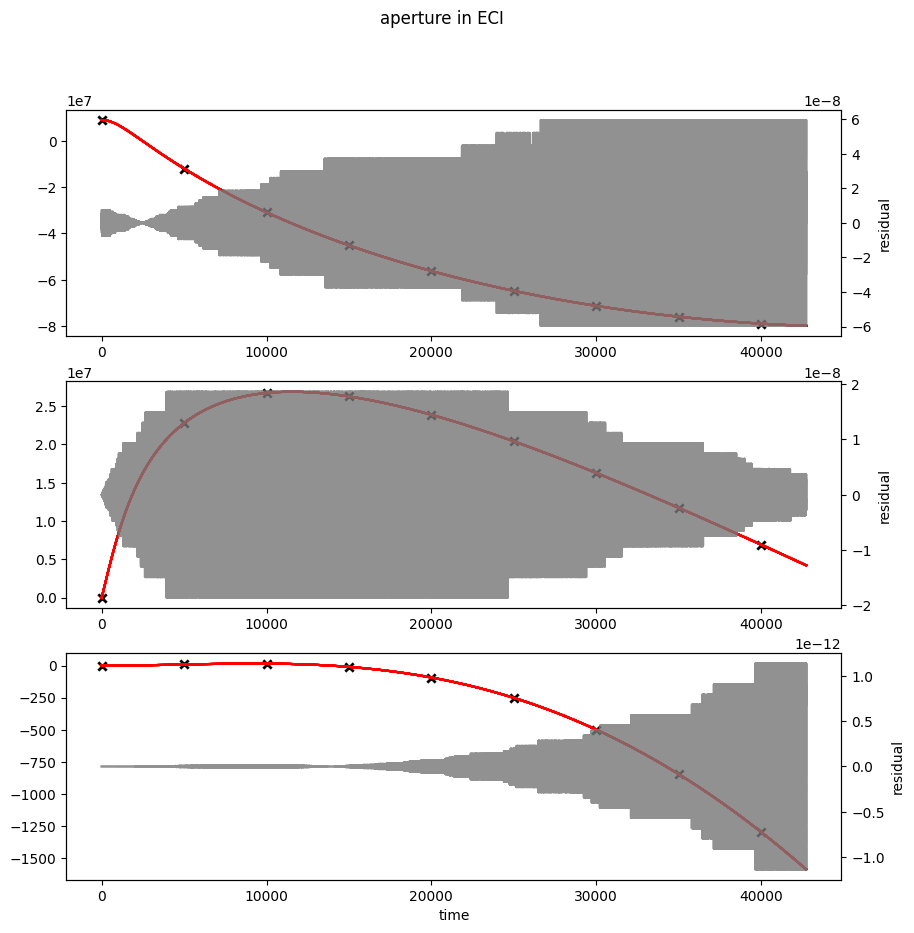

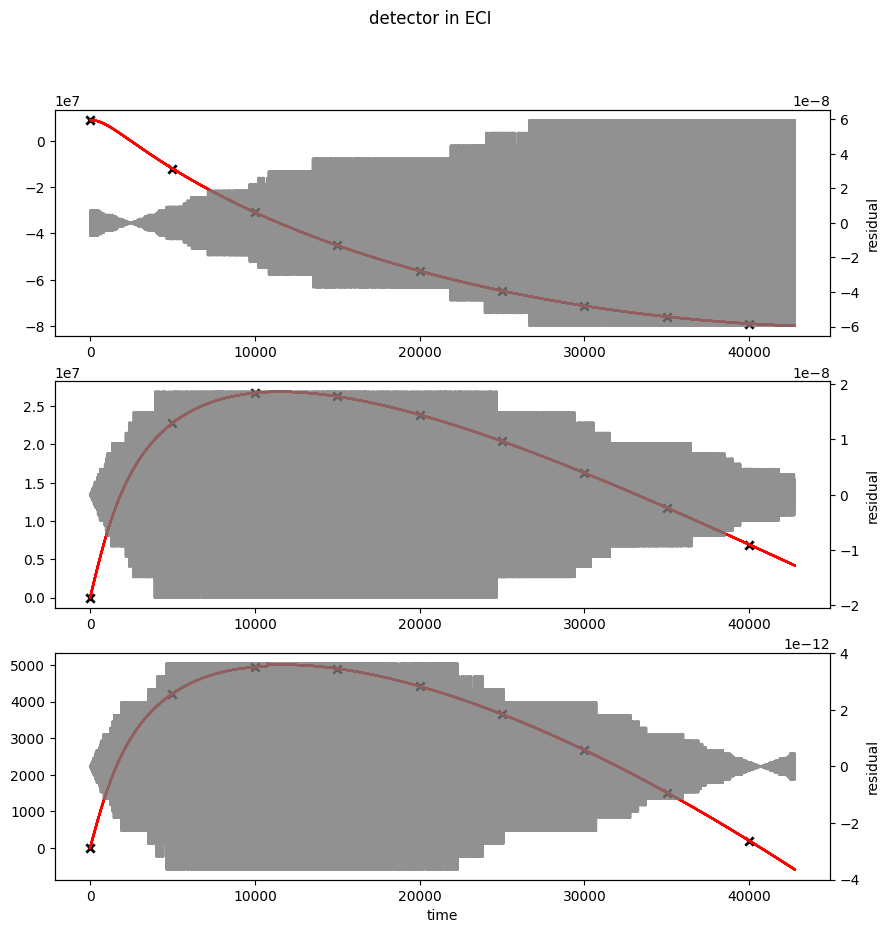

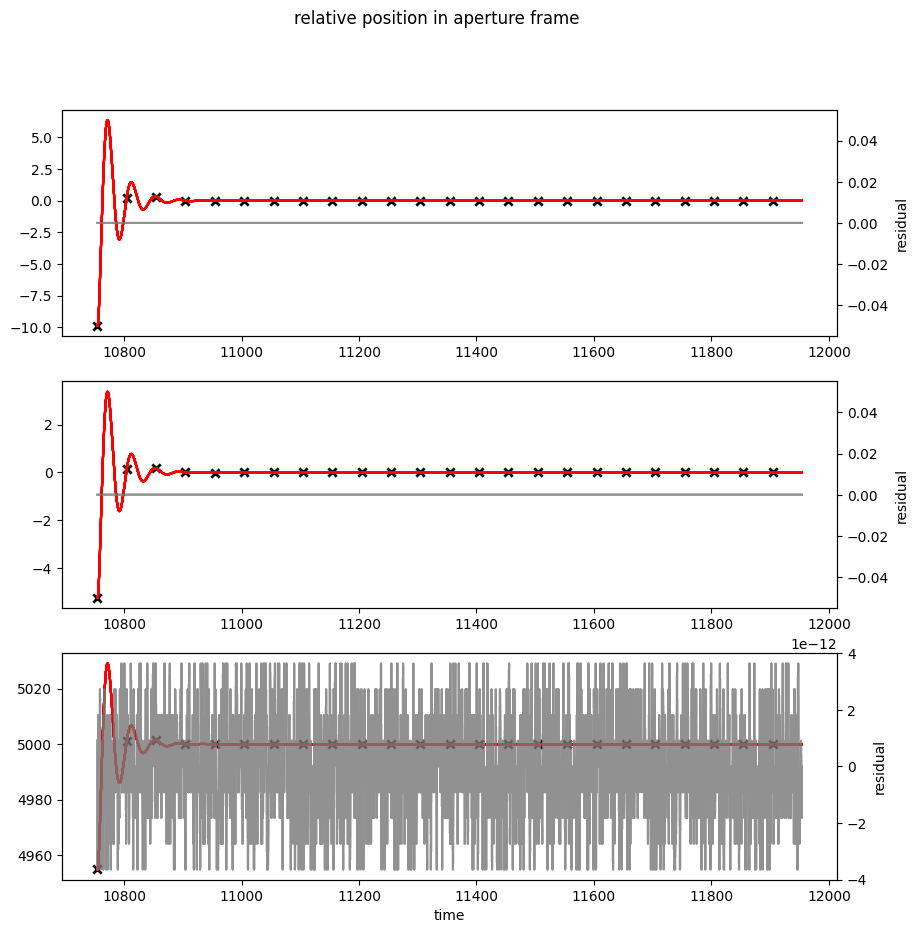

In [6]:
coord_letter = ['x', 'y', 'z']
alpha_residuals = 1 - 0.2**(1/len(seed_list))  # ~0.024 for 29 seeds

# compute means across seeds (axis=0)
mean_r_app = np.mean(r_app_eci, axis=0)   # shape (N_time, 3)
mean_r_det = np.mean(r_det_eci, axis=0)
mean_rel   = np.mean(rel_pos_B, axis=0)
# make figs
app_eci_fig, app_eci_ax = plt.subplots(nrows=3, ncols=1, figsize=(10,10))
det_eci_fig, det_eci_ax = plt.subplots(nrows=3, ncols=1, figsize=(10,10))
rel_pos_fig, rel_pos_ax = plt.subplots(nrows=3, ncols=1, figsize=(10,10))
# give titles
app_eci_ax[2].set_xlabel('time')
det_eci_ax[2].set_xlabel('time')
rel_pos_ax[2].set_xlabel('time')
app_eci_fig.suptitle('aperture in ECI')
det_eci_fig.suptitle('detector in ECI')
rel_pos_fig.suptitle('relative position in aperture frame')
# Create all twin axes upfront as lists
ax2_app = [app_eci_ax[c].twinx() for c in range(len(coord_letter))]
ax2_det = [det_eci_ax[c].twinx() for c in range(len(coord_letter))]
ax2_rel = [rel_pos_ax[c].twinx() for c in range(len(coord_letter))]

# Residuals on twin axis (right, grey)
for seed in seed_list:
    for coord in range(len(coord_letter)):
        # normal plot on primary axis (red)
        app_eci_ax[coord].plot(full_time,    r_app_eci[seed-1, :, coord], color='red',  alpha=0.5)
        det_eci_ax[coord].plot(full_time,    r_det_eci[seed-1, :, coord], color='red',  alpha=0.5)
        rel_pos_ax[coord].plot(engaged_time, rel_pos_B[seed-1, :, coord], color='red',  alpha=0.5)

        # residual from mean on twin axis (grey)
        ax2_app[coord].plot(full_time,    r_app_eci[seed-1, :, coord] - mean_r_app[:, coord], color='grey', alpha=alpha_residuals)
        ax2_det[coord].plot(full_time,    r_det_eci[seed-1, :, coord] - mean_r_det[:, coord], color='grey', alpha=alpha_residuals)
        ax2_rel[coord].plot(engaged_time, rel_pos_B[seed-1, :, coord] - mean_rel[:, coord],   color='grey', alpha=alpha_residuals)

# Mean and labels
every = 100
for coord in range(len(coord_letter)):
    # mean on primary axis (black x markers)
    app_eci_ax[coord].scatter(full_time[::every*100],    mean_r_app[::every*100, coord], marker='x', color='black', lw=2, label='mean')
    det_eci_ax[coord].scatter(full_time[::every*100],    mean_r_det[::every*100, coord], marker='x', color='black', lw=2, label='mean')
    rel_pos_ax[coord].scatter(engaged_time[::every], mean_rel[::every, coord],   marker='x', color='black', lw=2, label='mean')

    ax2_app[coord].set_ylabel('residual')
    ax2_det[coord].set_ylabel('residual')
    ax2_rel[coord].set_ylabel('residual')




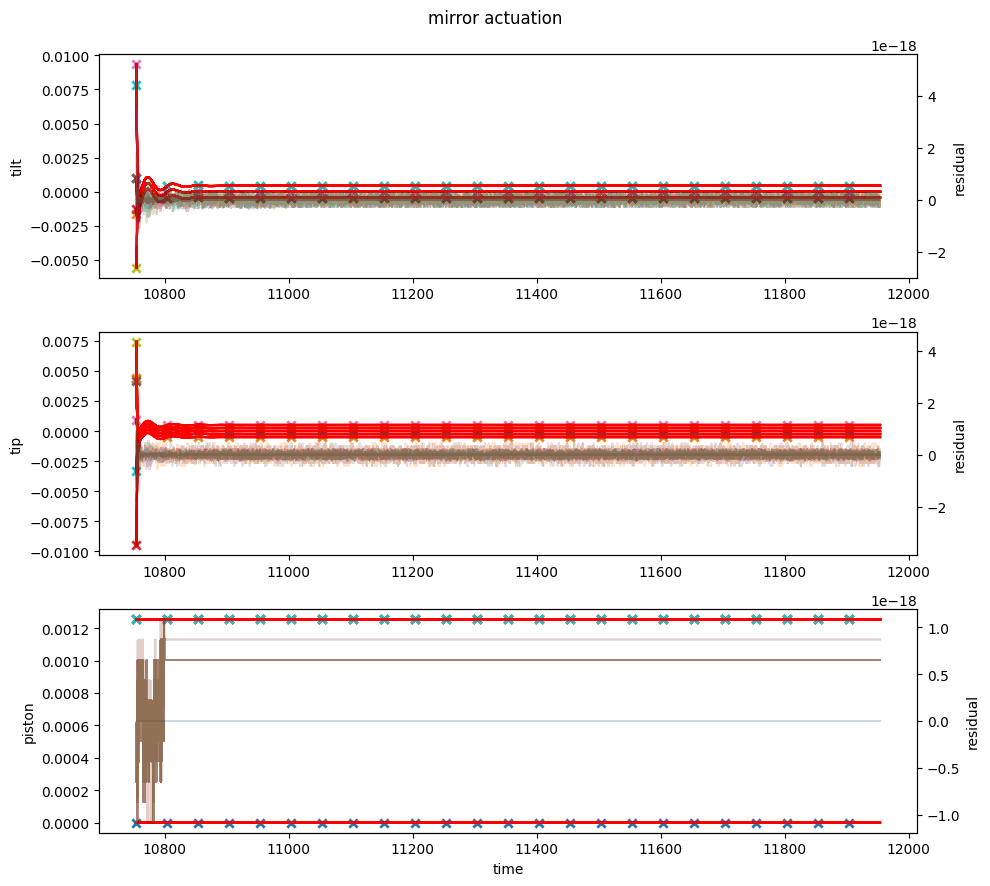

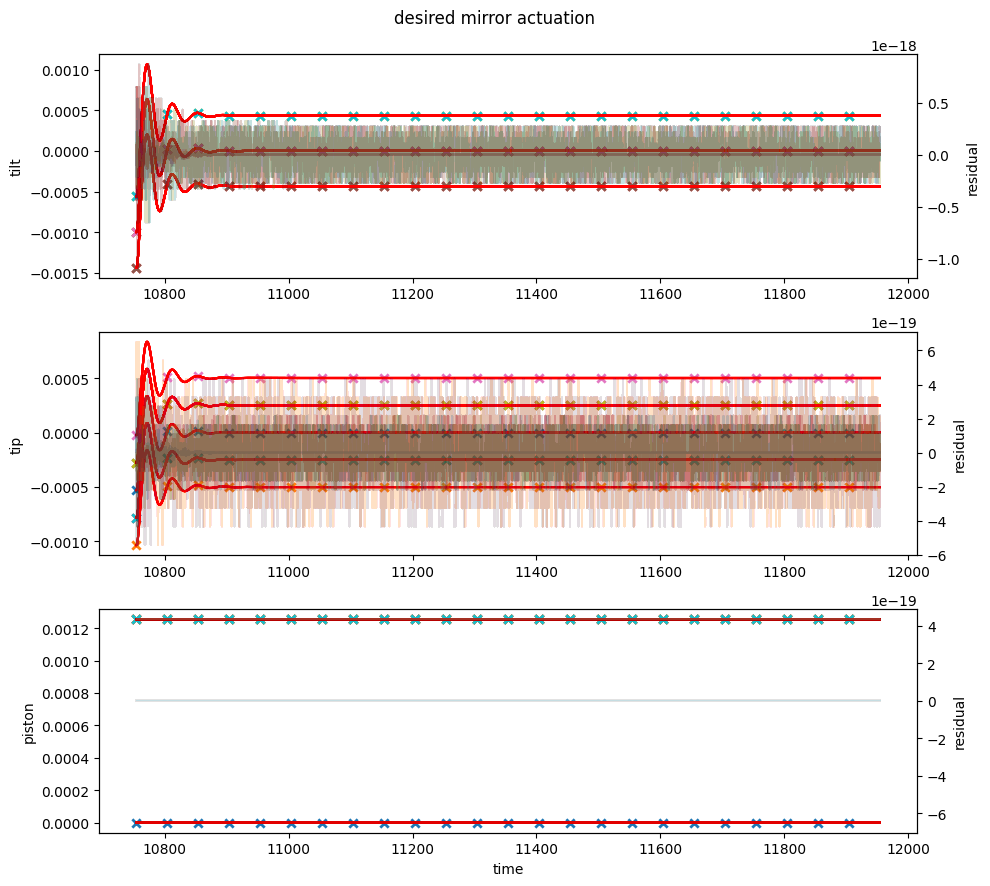

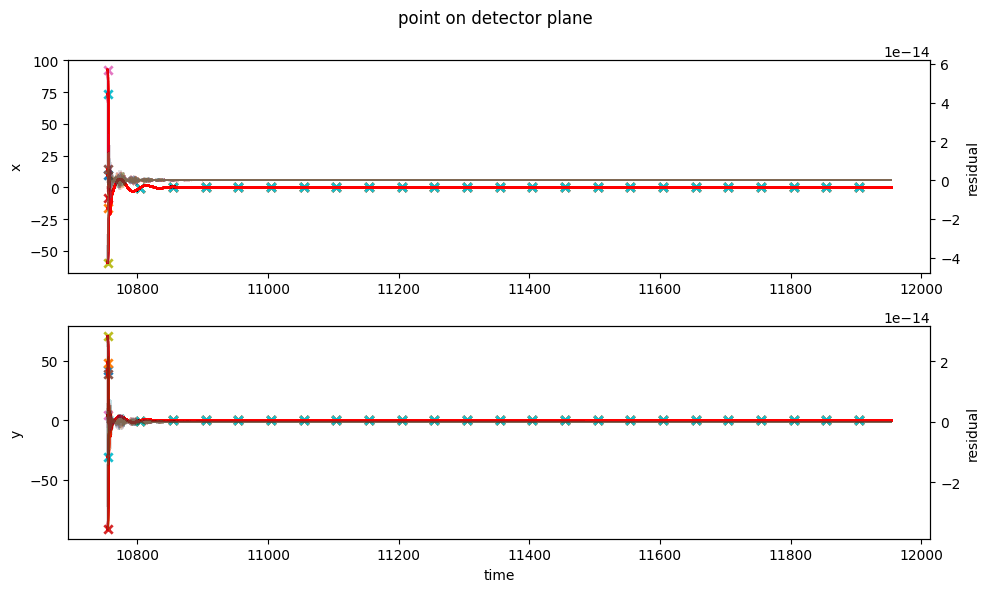

In [11]:
# ── derive shapes ──────────────────────────────────────────────────────────
n_segs       = mirror_actuation.shape[1]   # 7
zernike_list = ['tilt', 'tip', 'piston']  
n_ma         = len(zernike_list)
n_dp         = point_on_det_plane.shape[3] # 2 det-plane coords

alpha_seg = 1 - 0.2 ** (1 / (len(seed_list) * n_segs))
# Get a unique color for each segment
seg_colors = [plt.cm.tab10(i / max(n_segs - 1, 1)) for i in range(n_segs)]

# ── means over seeds only (axis=0), keeping segment axis ──────────────────
mean_ma  = np.mean(mirror_actuation,         axis=0)  # (n_segs, 2400, n_ma)
mean_dma = np.mean(desired_mirror_actuation, axis=0)  # (n_segs, 2400, n_ma)
mean_dp  = np.mean(point_on_det_plane,       axis=0)  # (n_segs, 2400, n_dp)

# ── figures ────────────────────────────────────────────────────────────────
ma_fig,  ma_ax  = plt.subplots(nrows=n_ma, ncols=1, figsize=(10, 3*n_ma))
dma_fig, dma_ax = plt.subplots(nrows=n_ma, ncols=1, figsize=(10, 3*n_ma))
dp_fig,  dp_ax  = plt.subplots(nrows=n_dp, ncols=1, figsize=(10, 3*n_dp))

ma_fig.suptitle('mirror actuation')
dma_fig.suptitle('desired mirror actuation')
dp_fig.suptitle('point on detector plane')

ma_ax[-1].set_xlabel('time')
dma_ax[-1].set_xlabel('time')
dp_ax[-1].set_xlabel('time')

# ── twin axes ──────────────────────────────────────────────────────────────
ax2_ma  = [ma_ax[c].twinx()  for c in range(n_ma)]
ax2_dma = [dma_ax[c].twinx() for c in range(n_ma)]
ax2_dp  = [dp_ax[c].twinx()  for c in range(n_dp)]

# ── plot every (seed, segment) combo ───────────────────────────────────────
for seed in seed_list:
    for s in range(n_segs):
        for coord in range(n_ma):
            ma_ax[coord].plot(engaged_time,
                              mirror_actuation[seed-1, s, :, coord],
                              color='red', alpha=0.3)
            ax2_ma[coord].plot(engaged_time,
                               mirror_actuation[seed-1, s, :, coord] - mean_ma[s, :, coord],
                               color=seg_colors[s], alpha=alpha_seg)

            dma_ax[coord].plot(engaged_time,
                               desired_mirror_actuation[seed-1, s, :, coord],
                               color='red', alpha=0.3)
            ax2_dma[coord].plot(engaged_time,
                                desired_mirror_actuation[seed-1, s, :, coord] - mean_dma[s, :, coord],
                                color=seg_colors[s], alpha=alpha_seg)

        for coord in range(n_dp):
            dp_ax[coord].plot(engaged_time,
                              point_on_det_plane[seed-1, s, :, coord],
                              color='red', alpha=0.3)
            ax2_dp[coord].plot(engaged_time,
                               point_on_det_plane[seed-1, s, :, coord] - mean_dp[s, :, coord],
                               color=seg_colors[s], alpha=alpha_seg)

# ── mean markers + axis labels ─────────────────────────────────────────────
every = 100
for coord in range(n_ma):
    for s in range(n_segs):
        ma_ax[coord].scatter(engaged_time[::every],  mean_ma[s, ::every, coord],
                             marker='x', color=seg_colors[s], lw=2)
        dma_ax[coord].scatter(engaged_time[::every], mean_dma[s, ::every, coord],
                              marker='x', color=seg_colors[s], lw=2)
    ma_ax[coord].set_ylabel(f'{zernike_list[coord]}')
    dma_ax[coord].set_ylabel(f'{zernike_list[coord]}')
    ax2_ma[coord].set_ylabel('residual')
    ax2_dma[coord].set_ylabel('residual')

for coord in range(n_dp):
    for s in range(n_segs):
        dp_ax[coord].scatter(engaged_time[::every], mean_dp[s, ::every, coord],
                             marker='x', color=seg_colors[s], lw=2)
    dp_ax[coord].set_ylabel(['x', 'y'][coord])
    ax2_dp[coord].set_ylabel('residual')

for fig in (ma_fig, dma_fig, dp_fig):
    fig.tight_layout()

plt.show()
